In [2]:
# We connect Google Colab to Google Drive, to ensure your notebook (the .ipynb file) is saved and accessible at any time for future use or download
from google.colab import drive
drive.mount('/content/gdrive')
# You can create the folder directly in Colab using the command below; you can change the folder -  ex.: '/content/gdrive/MyDrive/Project_1'
!mkdir -p '/content/gdrive/MyDrive/TF_Project'
print("Folder created successfully")

Mounted at /content/gdrive
Folder created successfully


In [3]:
# Add the path for the Python code for your project folder
import sys
sys.path.append('/content/gdrive/MyDrive/TF_Project')

In [4]:
# Connect the Matplotlib library to visualize images in the model from the your folder
from IPython.display import Image
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans']
matplotlib.rcParams['text.usetex'] = False

In [5]:
import tensorflow as tf
print(tf.test.is_built_with_cuda())
GPU=tf.config.experimental.list_physical_devices('GPU')
print("Num GPUs Available: ", len(GPU))
if GPU:
    try:
        for gpu in GPU:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth set for GPU.")
    except RuntimeError as e:
        print(e)
h = tf.constant("Hello")
w = tf.constant(" World!")
hw = h+w
print(hw.numpy().decode("utf-8"))

True
Num GPUs Available:  1
Memory growth set for GPU.
Hello World!


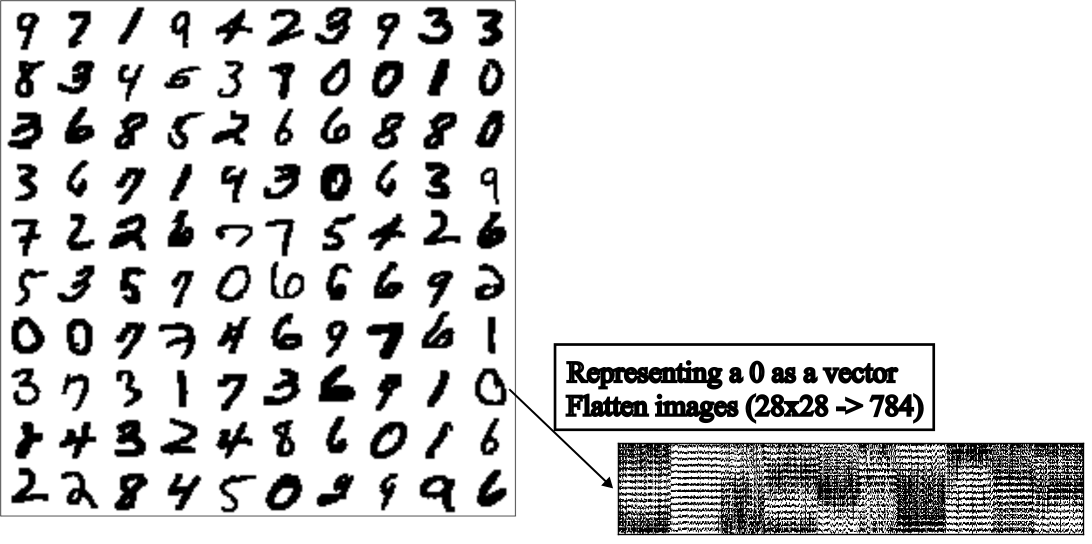

In [6]:
# Configure the path if needed, mainly due to the name of your folder: /content/gdrive/MyDrive/name_folder/MNIST.png
Image('/content/gdrive/MyDrive/TF_Project/MNIST.png', width=700)

In [7]:
%pip install "pandas>=2.0,<3.0" meteostat

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 114.9 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 46.9 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


Temperature : (43824,) → [5.  4.6 4.4]
Humidity    : (43824,) → [90 93 94]
Pressure    : (43824,) → [1006.4 1006.6 1007.1]
Precipitation: (43824,) → [nan 0.4 1. ]


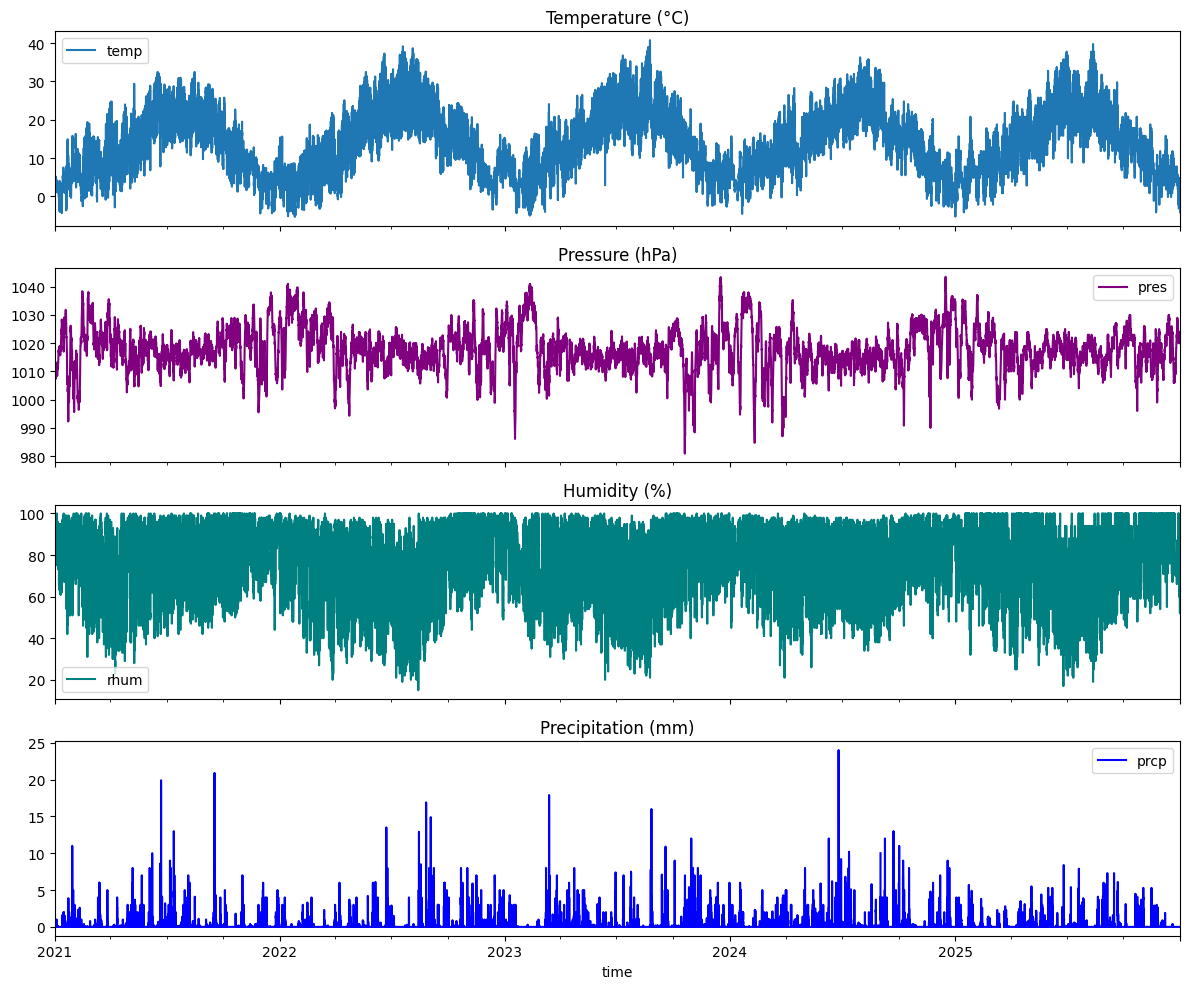

In [10]:
from datetime import date
import matplotlib.pyplot as plt
import meteostat as ms

# In cases of ranges > 3 years, Meteostat blocks hourly requests by default.
# Disable this guard for your long-range test (use responsibly).
ms.config.block_large_requests = False

# Specify location and time range
POINT = ms.Point(45.641632, 5.869613, 113)  # Try with your location
START = date(2021, 1, 1)
END = date(2025, 12, 31)

# Get nearby weather stations
stations = ms.stations.nearby(POINT, limit=4)

# Get hourly data & perform interpolation
ts = ms.hourly(stations, START, END)
df = ms.interpolate(ts, POINT).fetch()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

df.plot(ax=axes[0], y=[ms.Parameter.TEMP], title="Temperature (°C)")
df.plot(ax=axes[1], y=[ms.Parameter.PRES], title="Pressure (hPa)", color="purple")
df.plot(ax=axes[2], y=[ms.Parameter.RHUM], title="Humidity (%)", color="teal")
df.plot(ax=axes[3], y=[ms.Parameter.PRCP], title="Precipitation (mm)", color="blue")

# Extract each parameter into its own array
temp   = df[ms.Parameter.TEMP].to_numpy()
tmin   = df[ms.Parameter.TMIN].to_numpy() if ms.Parameter.TMIN in df.columns else None
tmax   = df[ms.Parameter.TMAX].to_numpy() if ms.Parameter.TMAX in df.columns else None
pres   = df[ms.Parameter.PRES].to_numpy()
rhum   = df[ms.Parameter.RHUM].to_numpy()
prcp   = df[ms.Parameter.PRCP].to_numpy()

# The date index can also be saved as an array
dates  = df.index.to_numpy()

print(f"Temperature : {temp.shape} → {temp[:3]}")
print(f"Humidity    : {rhum.shape} → {rhum[:3]}")
print(f"Pressure    : {pres.shape} → {pres[:3]}")
print(f"Precipitation: {prcp.shape} → {prcp[:3]}")

plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ── 1. Build features (X) and labels (y) from your arrays ──────────────────
# Stack your 3 input features → shape (N, 3)
X = np.column_stack([pres, temp, rhum]).astype(np.float32)

# Label: 1 = rain (prcp > 0.5 mm threshold), 0 = no rain
y = (prcp > 0.5).astype(np.float32)

# ── 2. Remove rows with NaN values ─────────────────────────────────────────
mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
X, y = X[mask], y[mask]

print(f"Dataset size : {len(X)} days")
print(f"Rainy days   : {y.sum():.0f} ({y.mean()*100:.1f}%)")
print(f"Dry days     : {(1-y).sum():.0f} ({(1-y.mean())*100:.1f}%)")

# ── 3. Normalize features to [0, 1] ────────────────────────────────────────
X_min = X.min(axis=0)
X_max = X.max(axis=0)
X_norm = (X - X_min) / (X_max - X_min)

# ── 4. Train / test split (80% / 20%) ──────────────────────────────────────
x_train, x_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, random_state=42, stratify=y
)

# ── 5. TensorFlow datasets ──────────────────────────────────────────────────
batch_size = 32
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(1000).batch(batch_size)
test_dataset  = tf.data.Dataset.from_tensor_slices((x_test,  y_test )).batch(batch_size)

# ── 6. Define the model ─────────────────────────────────────────────────────
num_features      = 3    # pres, temp, rhum

model = models.Sequential([
    layers.Dense(64,      activation="relu", input_shape=(num_features,)),
    layers.Dense(32, activation="relu"),
    #layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")  # Rain probability in [0, 1]
])

# ── 7. Compile ──────────────────────────────────────────────────────────────
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',     # Binary problem → not categorical_crossentropy
    metrics=['accuracy']
)
model.summary()

# ── 8. Train ────────────────────────────────────────────────────────────────
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=test_dataset
)

# ── 9. Evaluate ─────────────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")

# ── 10. Save ────────────────────────────────────────────────────────────────
model.save(f"rain_model_Accu{test_acc:.4f}.keras")

# ── 11. Plot training curves (replaces AccuracyPlotCallback) ────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()

# ── 12. Predict on new data ─────────────────────────────────────────────────
def predict_rain(pressure, temperature, humidity):
    sample = np.array([[pressure, temperature, humidity]], dtype=np.float32)
    sample_norm = (sample - X_min) / (X_max - X_min)   # Same normalization as training
    prob = model.predict(sample_norm, verbose=0)[0][0]
    label = "🌧  Rain" if prob > 0.5 else "☀️  No rain"
    print(f"Rain probability: {prob:.1%}  →  {label}")

# Example usage
predict_rain(pressure=1008, temperature=12, humidity=85)
predict_rain(pressure=1022, temperature=18, humidity=40)

# ── 13. Export to TFLite for Cube.AI ────────────────────────────────────────
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Save directly to your Drive
with open("/content/drive/MyDrive/rain_model.tflite", "wb") as f:
    f.write(tflite_model)

print(f"TFLite model size: {len(tflite_model) / 1024:.1f} KB")
print(f"X_min: {X_min}")
print(f"X_max: {X_max}")
print("Modèle sauvegardé dans Google Drive ✅")

Mounted at /content/drive
TFLite model size: 11.3 KB
X_min: [980.9  -5.4  15. ]
X_max: [1043.5   40.8  100. ]
Modèle sauvegardé dans Google Drive ✅


In [12]:
# Run this in Colab to confirm the model is valid before exporting
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input shape :", input_details[0]['shape'])   # should be [1, 3]
print("Input dtype :", input_details[0]['dtype'])   # should be float32
print("Output shape:", output_details[0]['shape'])  # should be [1, 1]
print("Model is valid ✅")

Input shape : [1 3]
Input dtype : <class 'numpy.float32'>
Output shape: [1 1]
Model is valid ✅


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
